# Polynomial Regression: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Polynomial Regression** in Python.

### Concept Overview
Models relationships where target variations describe curved non-linear patterns using polynomial features transformations.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
y = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_d x^d + \epsilon
$$

### Real-World Analogy
**Analogy:** The trajectory of a thrown ball (gravity shapes a curved quadratic parabola path).

### Worked Example
**Worked Example:** Chemical yield vs. Temperature. Yield curves up and then down due to boiling. A 2nd-degree polynomial yield = 50 + 2*Temp - 0.05*Temp^2 defines maximum yield at 20 degrees.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of non-linear chemical yield dataset
np.random.seed(42)
X_data = np.random.uniform(-10, 40, 400)
noise = np.random.normal(0, 4, 400)
y_data = 50 + 2.5 * X_data - 0.08 * (X_data ** 2) + noise
df = pd.DataFrame({
    'Temperature': np.round(X_data, 1),
    'Yield': np.round(y_data, 2)
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (400, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  400 non-null    float64
 1   Yield        400 non-null    float64
dtypes: float64(2)
memory usage: 6.4 KB
       Temperature       Yield
count   400.000000  400.000000
mean     14.709750   52.147450
std      14.688037   15.993311
min      -9.700000    9.120000
25%       2.075000   39.702500
50%      15.600000   55.325000
75%      27.350000   65.615000
max      39.500000   79.740000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 Temperature    0
Yield          0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We perform visual analysis of the dataset, examining correlation heatmaps and target-colored feature distributions to understand the underlying boundaries.

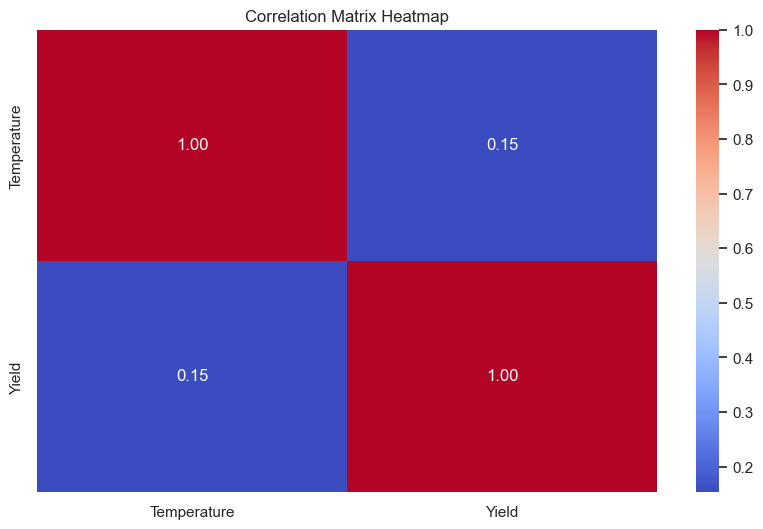

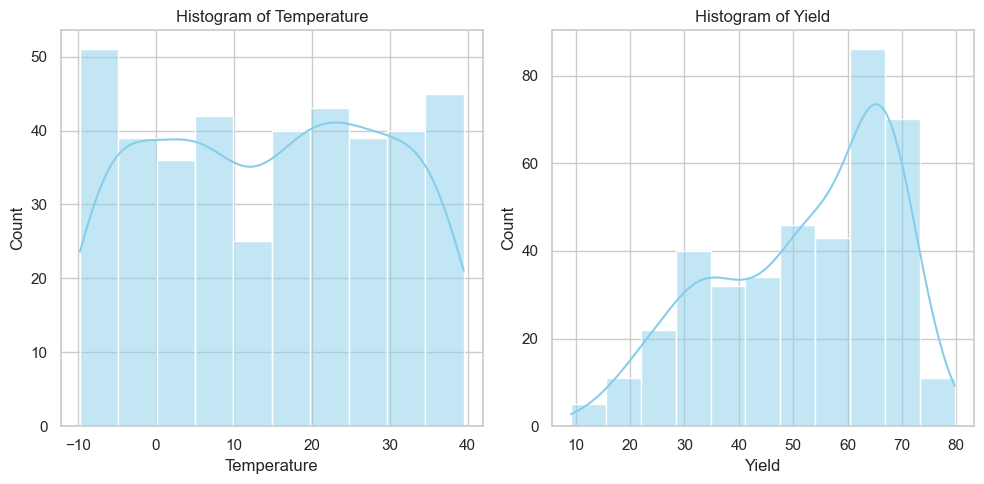

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Histograms of features and target
fig, axes = plt.subplots(1, len(df.columns), figsize=(5 * len(df.columns), 5))
if len(df.columns) == 1:
    sns.histplot(df.iloc[:, 0], kde=True, ax=axes, color='skyblue')
    axes.set_title(f'Histogram of {df.columns[0]}')
else:
    for idx, col in enumerate(df.columns):
        sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
        axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print('Scaling not strictly needed for this model.')

Scaling not strictly needed for this model.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (280, 1), Test size: (120, 1)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model = LinearRegression()
model.fit(X_train_poly, y_train)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 0.          2.59335203 -0.0833129 ]
Intercept: 49.96735787888193


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test_poly)
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 3.0111152392954343
RMSE: 3.6840923129262273
R2 Score: 0.9285106828687713


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

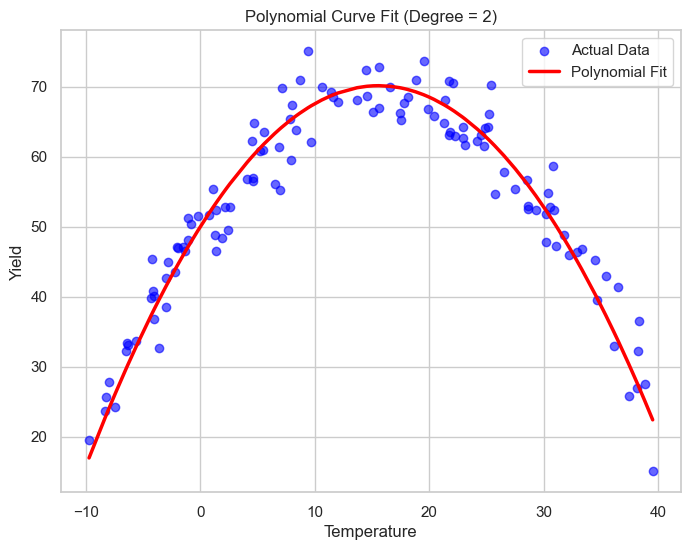

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual Data')
# Sort values for smooth curve plotting
sort_idx = np.argsort(X_test.iloc[:, 0])
plt.plot(X_test.iloc[sort_idx, 0], y_pred[sort_idx], color='red', linewidth=2.5, label='Polynomial Fit')
plt.title('Polynomial Curve Fit (Degree = 2)')
plt.xlabel('Temperature')
plt.ylabel('Yield')
plt.legend()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: How does Polynomial Regression avoid linear limits?**

*A: It transforms the feature space by creating cross-product and power terms (e.g. x^2, x^3) allowing OLS to find linear hyperplane separators in higher dimensions.*

**Q2: What is the danger of setting the degree parameter too high?**

*A: Setting the degree too high leads to severe overfitting, where the model fits the noise of the training data rather than the underlying pattern.*

**Q3: Is Polynomial Regression considered a linear model?**

*A: Yes, it is linear in terms of its parameters (coefficients beta) even though the features are raised to non-linear power terms.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What class creates polynomial features in scikit-learn?**

*A: `PolynomialFeatures` from `sklearn.preprocessing`.*

**Q2: What does the 'degree' parameter mean?**

*A: It specifies the highest power term generated during feature engineering transformations.*

**Q3: Why do we fit_transform on train but only transform on test?**

*A: To prevent data leakage by estimating feature means/ranges solely from the training partition.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.